IMPLEMENTATION OF LOGISTIC REGRESSION

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs

In [8]:
# 1. Create Dataset
X, y = make_blobs(n_samples = 1000, n_features = 2, centers=2, random_state=0) 
# basically you can make your regression/classification dataset through such methods. It is one of them 
dataset_array = np.concatenate((X, y.reshape(-1,1)), axis=1)

# 2. Create a Dataframe of the array
dataset_df = pd.DataFrame(dataset_array, columns = ['Col 1', 'Col 2', 'Target'])

dataset_df

,Col 1,Col 2,Target
0,0.466618,3.865713,0.0
1,2.843828,3.326509,0.0
2,0.611215,2.512460,0.0
3,3.816534,1.651759,1.0
4,1.280972,0.628274,1.0
...,...,...,...
995,2.168005,1.554931,1.0
996,1.171340,2.522224,0.0
997,2.083030,0.472121,1.0
998,1.441933,2.767544,0.0


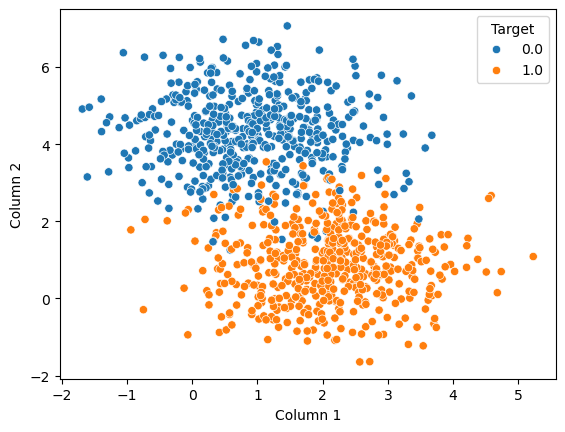

In [9]:
sns.scatterplot(data=dataset_df, x='Col 1', y='Col 2', hue='Target')
plt.xlabel("Column 1")
plt.ylabel("Column 2")
plt.show()

FUNCTIONS FOR LOGISTIC REGRESSION

In [ ]:
# Build a logistic regression classifier

# 0. Helper function: Sigmoid
def sigmoid(x):
    
    '''
    sigmoid(x) = 1 / (1 + e^(-x))
    '''
    return 1 / (1 + np.exp(-x))

# 1. Hypothesis
def hypothesis(x, theta):
    
    # h(x) = sigmoid(X.theta)
    z = np.dot(x, theta)
    
    return sigmoid(z)

# 2. Loss Function: Binary Cross Entropy
# to get better idea try to print all of these by adding print statement in the function itself
def binary_cross_entropy(x, y, theta): # Usually we consider binary_cross_entropy as loss function(NOT ALWAYS) for binary classification
    
    m, n = x.shape 
    # print(x.shape)
    # a. Compute the hypothesis
    y_hat = hypothesis(x, theta)
    # print(y_hat)
    # b. Compute the Binary Cross Entropy
    loss = y * np.log(y_hat) + (1 - y) * np.log(1 - y_hat)
    # print(np.log(y_hat))
    
    # print(np.log(1 - y_hat))
    # print( np.mean(loss) )
    return - np.mean(loss) 

# 3. Compute the gradient
def gradient(x, y, theta):
    
    # Compute hypothesis
    y_hat = hypothesis(x, theta)
    
    # Compute gradient
    grad = np.dot( x.T, (y - y_hat))
    
    return - grad / x.shape[0] 

# 4. Gradient Descent
def gradient_descent(x, y, n_iter = 100, alpha = 0.1): # Try to mingle with n_iter and alpha to see what happens when you change them
    
    # a. Randomly initialise theta
    m,n = x.shape
    theta = np.zeros(shape = (n, ))
    
    # List to store the error
    error = []
    
    # b. Perform the gradient descent
    for i in range(n_iter):
        '''
        y_hat = hypothesis(x, theta)
        print(y_hat, y_hat.shape)
        '''
        
        # b.1. Compute the loss
        loss = binary_cross_entropy(x, y, theta)
        error.append(loss)
        
        # b.2. Compute Gradient
        grad = gradient(x, y, theta)
        
        # b.3. Perform the update rule
        theta = theta - alpha * grad
        
    return theta, error